# 04 — Active learning with Kratos as the oracle

`physicsnemo.active_learning` orchestrates train → metrology → query → label cycles.
Its `LabelStrategy` protocol is designed to wrap an expensive external solver — here,
that solver is **Kratos**: the query strategy proposes design points, and every one is
labeled by an actual Kratos analysis run through `KratosLabelStrategy`.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo   # optional runtime dependencies of the application
> ```
>
> Everything below runs on CPU in a few seconds; outputs are written to `./output/`.

In [1]:
import json
import queue
import sys
from pathlib import Path

import torch

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication.active_learning.sample_io import KratosALSample
from KratosMultiphysics.PhysicsNeMoApplication.active_learning.execution_backends.in_process_backend import InProcessBackend
from KratosMultiphysics.PhysicsNeMoApplication.active_learning.kratos_label_strategy import CreateKratosLabelStrategy

from physicsnemo.active_learning.driver import Driver
from physicsnemo.active_learning.config import DriverConfig, StrategiesConfig, TrainingConfig
from physicsnemo.active_learning.protocols import QueryStrategy

torch.manual_seed(0)
Path("output").mkdir(exist_ok=True)

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

## The Kratos case

A minimal parametrized analysis (in a real setup this is your production
`AnalysisStage` + `ProjectParameters.json`): it "solves" `PRESSURE = α·x` on a line of
nodes. The analysis module must be importable, so it is written next to this notebook.

In [2]:
Path("al_dummy_analysis.py").write_text('''
import KratosMultiphysics as Kratos

def Create(model, parameters):
    return DummyAnalysis(model, parameters)

class DummyAnalysis:
    def __init__(self, model, parameters):
        self.model = model
        self.parameters = parameters

    def Run(self):
        alpha = self.parameters["dummy_settings"]["alpha"].GetDouble()
        model_part = self.model.CreateModelPart("Main")
        model_part.AddNodalSolutionStepVariable(Kratos.PRESSURE)
        for i in range(11):
            node = model_part.CreateNewNode(i + 1, i / 10.0, 0.0, 0.0)
            node.SetSolutionStepValue(Kratos.PRESSURE, alpha * node.X)
''')
if "." not in sys.path:
    sys.path.insert(0, ".")

Path("al_parameters.json").write_text(json.dumps(
    {"dummy_settings": {"alpha": 1.0}}, indent=4))

54

## Backend + label strategy

The `InProcessBackend` runs the analysis in this interpreter and extracts the output
fields straight from the in-memory `Model`. Each queued `KratosALSample` carries its
design point as JSON-path overrides applied to the case parameters.

In [3]:
backend = InProcessBackend(Kratos.Parameters("""{
    "project_parameters_file" : "al_parameters.json",
    "analysis_stage_module"   : "al_dummy_analysis",
    "working_directory"       : "output/al_cases",
    "model_part_name"         : "Main",
    "output_field_specs"      : [ { "variable_name" : "PRESSURE", "data_location" : "node_historical" } ]
}"""))
label_strategy = CreateKratosLabelStrategy(backend, provides_fields={"PRESSURE__node_historical"})
print("external process:", label_strategy.__is_external_process__)

external process: False


## A toy query strategy and learner

The query strategy proposes the α values the (toy) learner is most uncertain about —
here simply fixed picks, standing in for entropy/ensemble-disagreement heuristics.

In [4]:
class ToyQueryStrategy(QueryStrategy):
    __protocol_name__ = "ToyQueryStrategy"
    max_samples = 3

    def __init__(self):
        self._driver = None

    def attach(self, other):
        self._driver = other

    @property
    def is_attached(self):
        return self._driver is not None

    def sample(self, query_queue, *args, **kwargs):
        for k, alpha in enumerate([0.5, 1.25, 3.0]):
            query_queue.put(KratosALSample(f"query_{k}",
                                           parameters={"dummy_settings/alpha": alpha}))

class TinyLearner(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

## One active-learning step

Training and metrology are skipped to spotlight the query → label contract. The driver
drains the label queue into `train_datapool` after labeling — that list is where the
newly labeled samples end up.

In [5]:
train_datapool = []
driver = Driver(
    config=DriverConfig(
        batch_size=1,
        max_active_learning_steps=1,
        skip_training=True,
        skip_metrology=True,
        checkpoint_interval=0,
        checkpoint_on_labeling=False,
        root_log_dir="output/al_logs"),
    learner=TinyLearner(),
    strategies_config=StrategiesConfig(
        query_strategies=[ToyQueryStrategy()],
        queue_cls=queue.Queue,
        label_strategy=label_strategy),
    training_config=TrainingConfig(train_datapool=train_datapool, max_training_epochs=1))

driver.active_learning_step()

for sample in train_datapool:
    pressure = sample.fields["PRESSURE__node_historical"]
    print(f"{sample.sample_id}: alpha={sample.parameters['dummy_settings/alpha']}, "
          f"PRESSURE[-1]={pressure[-1]:.3f}")
print("failed samples:", label_strategy.failed_samples)

2026-09-02 15:15:57,914 - core.active_learning - INFO - Starting active learning step 0 [run:46edf732-4c3d-4718-a665-3a5cd497b83c, iter:0]


2026-09-02 15:15:57,916 - core.active_learning - INFO - Running query strategy: ToyQueryStrategy [run:46edf732-4c3d-4718-a665-3a5cd497b83c, iter:0, phase:query]


2026-09-02 15:15:57,920 - core.active_learning - INFO - Labeling completed. Now appending to training pool. [run:46edf732-4c3d-4718-a665-3a5cd497b83c, iter:0, phase:labeling]


2026-09-02 15:15:57,921 - core.active_learning - INFO - Appended 3 samples to training pool. [run:46edf732-4c3d-4718-a665-3a5cd497b83c, iter:0, phase:labeling]


2026-09-02 15:15:57,923 - core.active_learning - INFO - Completed active learning step 1 [run:46edf732-4c3d-4718-a665-3a5cd497b83c, iter:1]


query_0: alpha=0.5, PRESSURE[-1]=0.500
query_1: alpha=1.25, PRESSURE[-1]=1.250
query_2: alpha=3.0, PRESSURE[-1]=3.000
failed samples: 0


### The labels Kratos produced

Each queried `alpha` became one Kratos run; its `PRESSURE` field is the label. Rendered with pyvista, one row of nodes per labelled case.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


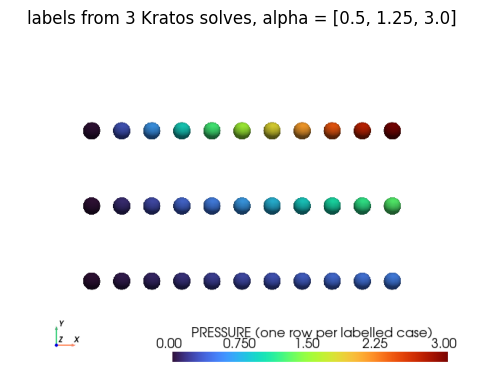

In [6]:
import numpy
import matplotlib.pyplot as plt
import pyvista as pv
from KratosMultiphysics import pyvista_utilities as pv_utils

def render_points(points, values, title, cmap="turbo", clim=None, point_size=14, view="iso"):
    """Off-screen pyvista render of a point cloud coloured by a scalar (numpy image)."""
    cloud = pv.PolyData(numpy.asarray(points, dtype=float))
    cloud["value"] = numpy.asarray(values, dtype=float).ravel()
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))
    plotter.add_points(cloud, scalars="value", cmap=cmap, clim=clim, point_size=point_size,
                       render_points_as_spheres=True, scalar_bar_args={"title": title})
    plotter.add_axes()
    plotter.view_xy() if view == "xy" else plotter.view_isometric()
    return plotter.screenshot(None)

points, values = [], []
for row, sample in enumerate(train_datapool):
    pressure = numpy.ravel(sample.fields["PRESSURE__node_historical"])
    for i, value in enumerate(pressure):
        points.append([i / 10.0, 0.25 * row, 0.0]); values.append(value)
img = render_points(points, values, "PRESSURE (one row per labelled case)", view="xy", point_size=24)
plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis("off")
plt.title("labels from %d Kratos solves, alpha = %s" % (len(train_datapool), [s.parameters['dummy_settings/alpha'] for s in train_datapool]))
plt.tight_layout(); plt.savefig("output/labels.png", dpi=120, bbox_inches="tight"); plt.show()


## The built-in query-strategy library

Instead of writing a `QueryStrategy` by hand, the application ships three
ready-made ones in `active_learning.query_strategies`, all following the same
pattern: draw a candidate pool from your sampler, score it, enqueue the top
`max_samples` candidates as `KratosALSample`s:

- **`CreateEnsembleDisagreementStrategy`** — variance across an ensemble of
  checkpoints (`"ensemble_checkpoints"`: list of `LoadModel` settings),
- **`CreateEntropyStrategy`** — entropy over stochastic forward passes (dropout
  kept active),
- **`CreateSolverResidualStrategy`** — a user-supplied residual score, typically
  `solver_residuals.ResidualEvaluator` assembling the *actual PDE residual* of
  the surrogate's prediction (not differentiable — a score, never a loss).

Below, an ensemble of two deliberately different checkpoints of the toy learner
scores candidates by disagreement: the candidates farthest from the labeled
data disagree most and win.


In [7]:
from KratosMultiphysics.PhysicsNeMoApplication.active_learning import query_strategies

# two "ensemble members": the same architecture, different initializations
ensemble_settings = Kratos.Parameters('''{
    "max_samples"          : 2,
    "candidate_pool_size"  : 5,
    "ensemble_checkpoints" : []
}''')
for seed in (0, 1):
    torch.manual_seed(seed)
    member = torch.jit.script(torch.nn.Linear(1, 1).double())
    member.save(f"al_ensemble_member_{seed}.pt")
    entry = Kratos.Parameters('{ "checkpoint_file": "", "device": "auto" }')
    entry["checkpoint_file"].SetString(f"al_ensemble_member_{seed}.pt")
    ensemble_settings["ensemble_checkpoints"].Append(entry)

strategy = query_strategies.CreateEnsembleDisagreementStrategy(
    ensemble_settings,
    candidate_sampler=lambda n: [{"dummy_settings/alpha": a} for a in (-4.0, -1.0, 0.5, 2.0, 6.0)],
    encode_candidate=lambda c: torch.tensor([c["dummy_settings/alpha"]], dtype=torch.float64))

candidate_queue = queue.Queue()
strategy.sample(candidate_queue)
while not candidate_queue.empty():
    sample = candidate_queue.get()
    print(sample.sample_id, "->", sample.parameters)


query_000_00EnsembleDisagreementStrategy: Iteration 0: enqueued 2 of 5 candidates. 
 -> {'dummy_settings/alpha': -4.0}
query_000_01 -> {'dummy_settings/alpha': 6.0}


## Scaling up: the subprocess backend

For production use, swap `InProcessBackend` for `SubprocessBackend`: it copies a case
template per sample, patches its `ProjectParameters.json`, runs an external command
(with retries and a timeout) and harvests the `.npz` results written by the case's own
`DatasetExportProcess`. Two properties make it the recommended mode:

- Kratos MPI ranks and `torch.distributed` ranks stay in **separate OS processes**;
- a `["srun", ...]` or `["sbatch", "--wait", ...]` prefix in `run_command` turns
  labeling into HPC job submission with no extra code.

```python
backend = SubprocessBackend(Kratos.Parameters("""{
    "template_directory" : "my_case_template",
    "run_command"        : ["srun", "-n", "64", "python3", "MainKratos.py"]
}"""))
```